# Module 3 — U-Net: Crown–Stem–Peduncle Segmentation
**AIDA 2158A Final Project | Mark Miller**

This notebook:
1. Loads the 357 annotated image+mask pairs from `peduncle_masks/`
2. Builds a U-Net architecture in PyTorch
3. Trains U-Net to segment the crown–stem–peduncle region
4. Evaluates using IoU (Intersection over Union)
5. Visualises predictions vs ground truth masks

## Cell 1 — Imports & Paths

In [1]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2

PROJECT   = r"C:\Users\markm\Documents\RDP\AIDA 2158\Final Project"
IMGS_DIR  = os.path.join(PROJECT, "peduncle_masks", "images")
MASKS_DIR = os.path.join(PROJECT, "peduncle_masks", "masks")
RUNS_DIR  = os.path.join(PROJECT, "runs", "unet")
os.makedirs(RUNS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

all_imgs  = sorted(glob.glob(os.path.join(IMGS_DIR,  "*.png")))
all_masks = sorted(glob.glob(os.path.join(MASKS_DIR, "*.png")))
print(f"Total pairs: {len(all_imgs)}")

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
Total pairs: 357


## Cell 2 — Dataset & DataLoader

Images are resized to **256×256** for training — small enough to be fast, large enough to preserve peduncle structure.

Split: **300 train / 57 val** (roughly 84/16).

In [2]:
IMG_SIZE = 256   # resize all images to this square

class PeduncleDataset(Dataset):
    def __init__(self, img_paths, mask_paths, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.augment    = augment
        self.img_tf  = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225]),
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE),
                              interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = Image.open(self.img_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        # Simple augmentation: random horizontal flip
        if self.augment and random.random() > 0.5:
            img  = transforms.functional.hflip(img)
            mask = transforms.functional.hflip(mask)

        img  = self.img_tf(img)
        mask = self.mask_tf(mask)         # [1, H, W], values 0 or ~1
        mask = (mask > 0.5).float()       # binarise cleanly
        return img, mask


# Shuffle and split
indices = list(range(len(all_imgs)))
random.shuffle(indices)
split   = int(0.84 * len(indices))
train_idx = indices[:split]
val_idx   = indices[split:]

train_imgs  = [all_imgs[i]  for i in train_idx]
train_masks = [all_masks[i] for i in train_idx]
val_imgs    = [all_imgs[i]  for i in val_idx]
val_masks   = [all_masks[i] for i in val_idx]

train_ds = PeduncleDataset(train_imgs, train_masks, augment=True)
val_ds   = PeduncleDataset(val_imgs,   val_masks,   augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train: 299  |  Val: 58
Train batches: 38  |  Val batches: 8


## Cell 3 — U-Net Architecture

U-Net is the standard architecture for biomedical and agricultural image segmentation.
It has an **encoder** (downsampling path) that extracts features and a **decoder** (upsampling path)
that reconstructs the segmentation mask at full resolution. Skip connections between encoder and
decoder preserve spatial detail — critical for thin structures like stems.

```
Input (3×256×256)
  → Encoder block 1 (64)  ──────────────────────────────┐ skip
  → Encoder block 2 (128) ─────────────────────────┐ skip│
  → Encoder block 3 (256) ────────────────────┐ skip│    │
  → Encoder block 4 (512) ───────────────┐ skip│    │    │
  → Bottleneck      (1024)               │     │    │    │
  → Decoder block 4 (512) ←─────────────┘      │    │    │
  → Decoder block 3 (256) ←────────────────────┘    │    │
  → Decoder block 2 (128) ←─────────────────────────┘    │
  → Decoder block 1 (64)  ←──────────────────────────────┘
  → Output conv (1×256×256) → sigmoid → binary mask
```

In [3]:
def double_conv(in_ch, out_ch):
    """Two 3×3 convolutions each followed by BatchNorm + ReLU."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoders  = nn.ModuleList()
        self.pool      = nn.MaxPool2d(2, 2)
        self.decoders  = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        # Encoder
        ch = in_channels
        for f in features:
            self.encoders.append(double_conv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = double_conv(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.upsamples.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoders.append(double_conv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i, (up, dec) in enumerate(zip(self.upsamples, self.decoders)):
            x = up(x)
            skip = skips[i]
            # Handle odd-dimension mismatches
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = dec(x)

        return torch.sigmoid(self.final(x))


model = UNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters: {total_params:,}")
print(f"Model on: {next(model.parameters()).device}")

U-Net parameters: 31,037,633
Model on: cuda:0


## Cell 4 — Loss Function & Optimiser

**Loss: BCE + Dice combined**
- Binary Cross Entropy (BCE) penalises per-pixel prediction errors
- Dice loss directly optimises the IoU metric — important when the peduncle is a small region relative to the full image
- Combining both gives stable training and good segmentation quality

**Optimiser: Adam** with a cosine annealing learning rate schedule.

In [4]:
def dice_loss(pred, target, smooth=1.0):
    pred_flat   = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def bce_dice_loss(pred, target):
    bce  = nn.BCELoss()(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

def iou_score(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    union        = pred_bin.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)


EPOCHS = 50
LR     = 1e-3

optimiser = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS, eta_min=1e-5)

print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LR} (cosine annealed to 1e-5)")
print(f"Loss: BCE + Dice")
print(f"Optimiser: Adam")

Epochs: 50
Learning rate: 0.001 (cosine annealed to 1e-5)
Loss: BCE + Dice
Optimiser: Adam


## Cell 5 — Training Loop

In [5]:
history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}
best_val_iou  = 0.0
best_weights  = os.path.join(RUNS_DIR, "best_unet.pt")

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────
    model.train()
    train_loss, train_iou = 0.0, 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimiser.zero_grad()
        preds = model(imgs)
        loss  = bce_dice_loss(preds, masks)
        loss.backward()
        optimiser.step()
        train_loss += loss.item()
        train_iou  += iou_score(preds, masks).item()

    train_loss /= len(train_loader)
    train_iou  /= len(train_loader)

    # ── Validation ────────────────────────────────────────────
    model.eval()
    val_loss, val_iou = 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += bce_dice_loss(preds, masks).item()
            val_iou  += iou_score(preds, masks).item()

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), best_weights)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS} "
              f"| Train Loss: {train_loss:.4f}  IoU: {train_iou:.4f} "
              f"| Val Loss: {val_loss:.4f}  IoU: {val_iou:.4f}")

print(f"\nBest Val IoU: {best_val_iou:.4f}")
print(f"Best weights saved to: {best_weights}")

Epoch 001/50 | Train Loss: 1.3005  IoU: 0.0169 | Val Loss: 1.2245  IoU: 0.0189
Epoch 005/50 | Train Loss: 0.8735  IoU: 0.1753 | Val Loss: 0.8694  IoU: 0.1718
Epoch 010/50 | Train Loss: 0.7523  IoU: 0.2130 | Val Loss: 0.7485  IoU: 0.2291
Epoch 015/50 | Train Loss: 0.7140  IoU: 0.2359 | Val Loss: 0.8030  IoU: 0.1794
Epoch 020/50 | Train Loss: 0.7031  IoU: 0.2428 | Val Loss: 0.8304  IoU: 0.1651
Epoch 025/50 | Train Loss: 0.6906  IoU: 0.2504 | Val Loss: 0.7786  IoU: 0.1991
Epoch 030/50 | Train Loss: 0.6676  IoU: 0.2674 | Val Loss: 0.8029  IoU: 0.1795
Epoch 035/50 | Train Loss: 0.6559  IoU: 0.2763 | Val Loss: 0.8189  IoU: 0.1722
Epoch 040/50 | Train Loss: 0.6117  IoU: 0.3104 | Val Loss: 0.8427  IoU: 0.1559
Epoch 045/50 | Train Loss: 0.5996  IoU: 0.3196 | Val Loss: 0.8230  IoU: 0.1699
Epoch 050/50 | Train Loss: 0.5837  IoU: 0.3343 | Val Loss: 0.8346  IoU: 0.1625

Best Val IoU: 0.2291
Best weights saved to: C:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\unet\best_unet.pt


## Cell 6 — Training Curves

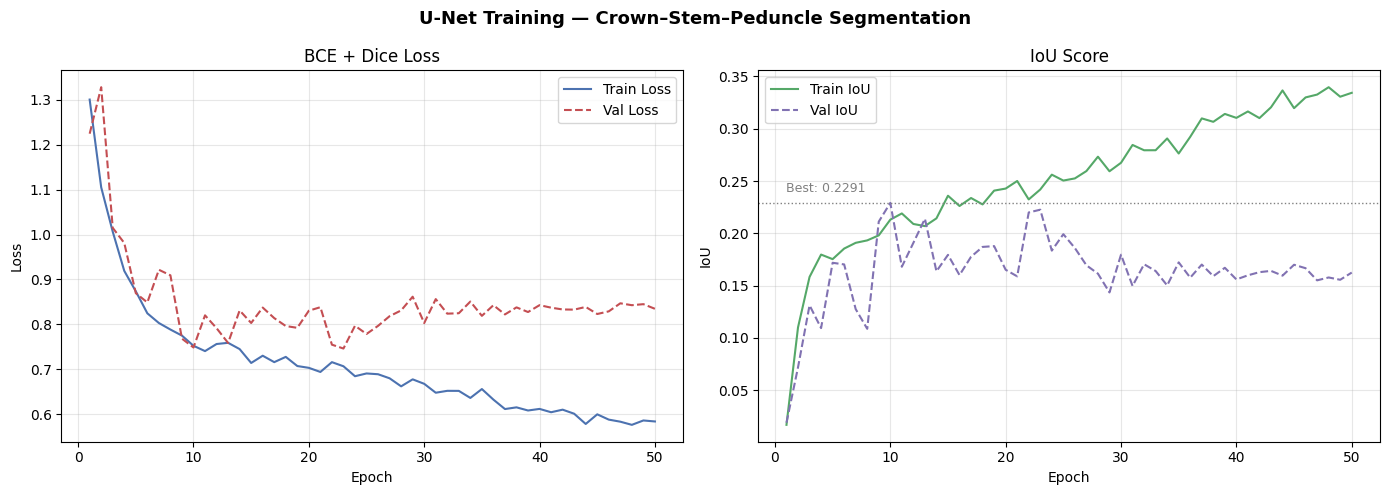

Saved: C:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\unet\unet_training_curves.png


In [6]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("U-Net Training — Crown–Stem–Peduncle Segmentation",
             fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss",      color='#4C72B0')
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",        color='#C44E52', linestyle='--')
axes[0].set_title("BCE + Dice Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU
axes[1].plot(epochs_range, history["train_iou"], label="Train IoU",        color='#55A868')
axes[1].plot(epochs_range, history["val_iou"],   label="Val IoU",          color='#8172B2', linestyle='--')
axes[1].axhline(best_val_iou, linestyle=':', color='gray', linewidth=1)
axes[1].text(1, best_val_iou + 0.01, f"Best: {best_val_iou:.4f}", color='gray', fontsize=9)
axes[1].set_title("IoU Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(RUNS_DIR, "unet_training_curves.png")
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {curve_path}")

## Cell 7 — Hyperparameter Table

In [7]:
import pandas as pd

hp = {
    "Parameter": ["Architecture", "Input size", "Encoder channels", "Epochs",
                  "Batch size", "Optimiser", "Learning rate", "LR schedule",
                  "Loss function", "Train samples", "Val samples", "Device"],
    "Value":     ["U-Net", "256×256", "64→128→256→512→1024", EPOCHS,
                  8, "Adam", LR, "Cosine annealing to 1e-5",
                  "BCE + Dice", len(train_ds), len(val_ds),
                  str(DEVICE)],
    "Reason":    [
        "Standard architecture for binary segmentation tasks",
        "Balances resolution vs GPU memory; captures peduncle detail",
        "Standard U-Net depth; sufficient for this scale of task",
        "Sufficient for convergence on 300 training samples",
        "Fits GPU memory; stable gradient updates",
        "Good default for segmentation; adaptive learning rates",
        "Standard starting point for U-Net training",
        "Smooth LR decay prevents oscillation at end of training",
        "Dice handles class imbalance (small peduncle vs large background)",
        "84% of 357 total annotated pairs",
        "16% of 357 total annotated pairs",
        "NVIDIA GeForce RTX 5070 Laptop GPU",
    ]
}

hp_df = pd.DataFrame(hp)
print(hp_df.to_string(index=False))

       Parameter                    Value                                                            Reason
    Architecture                    U-Net               Standard architecture for binary segmentation tasks
      Input size                  256×256       Balances resolution vs GPU memory; captures peduncle detail
Encoder channels      64→128→256→512→1024           Standard U-Net depth; sufficient for this scale of task
          Epochs                       50                Sufficient for convergence on 300 training samples
      Batch size                        8                          Fits GPU memory; stable gradient updates
       Optimiser                     Adam            Good default for segmentation; adaptive learning rates
   Learning rate                    0.001                        Standard starting point for U-Net training
     LR schedule Cosine annealing to 1e-5           Smooth LR decay prevents oscillation at end of training
   Loss function            

## Cell 8 — Visual Predictions vs Ground Truth
Shows 6 val images: original | ground truth mask | predicted mask | overlay

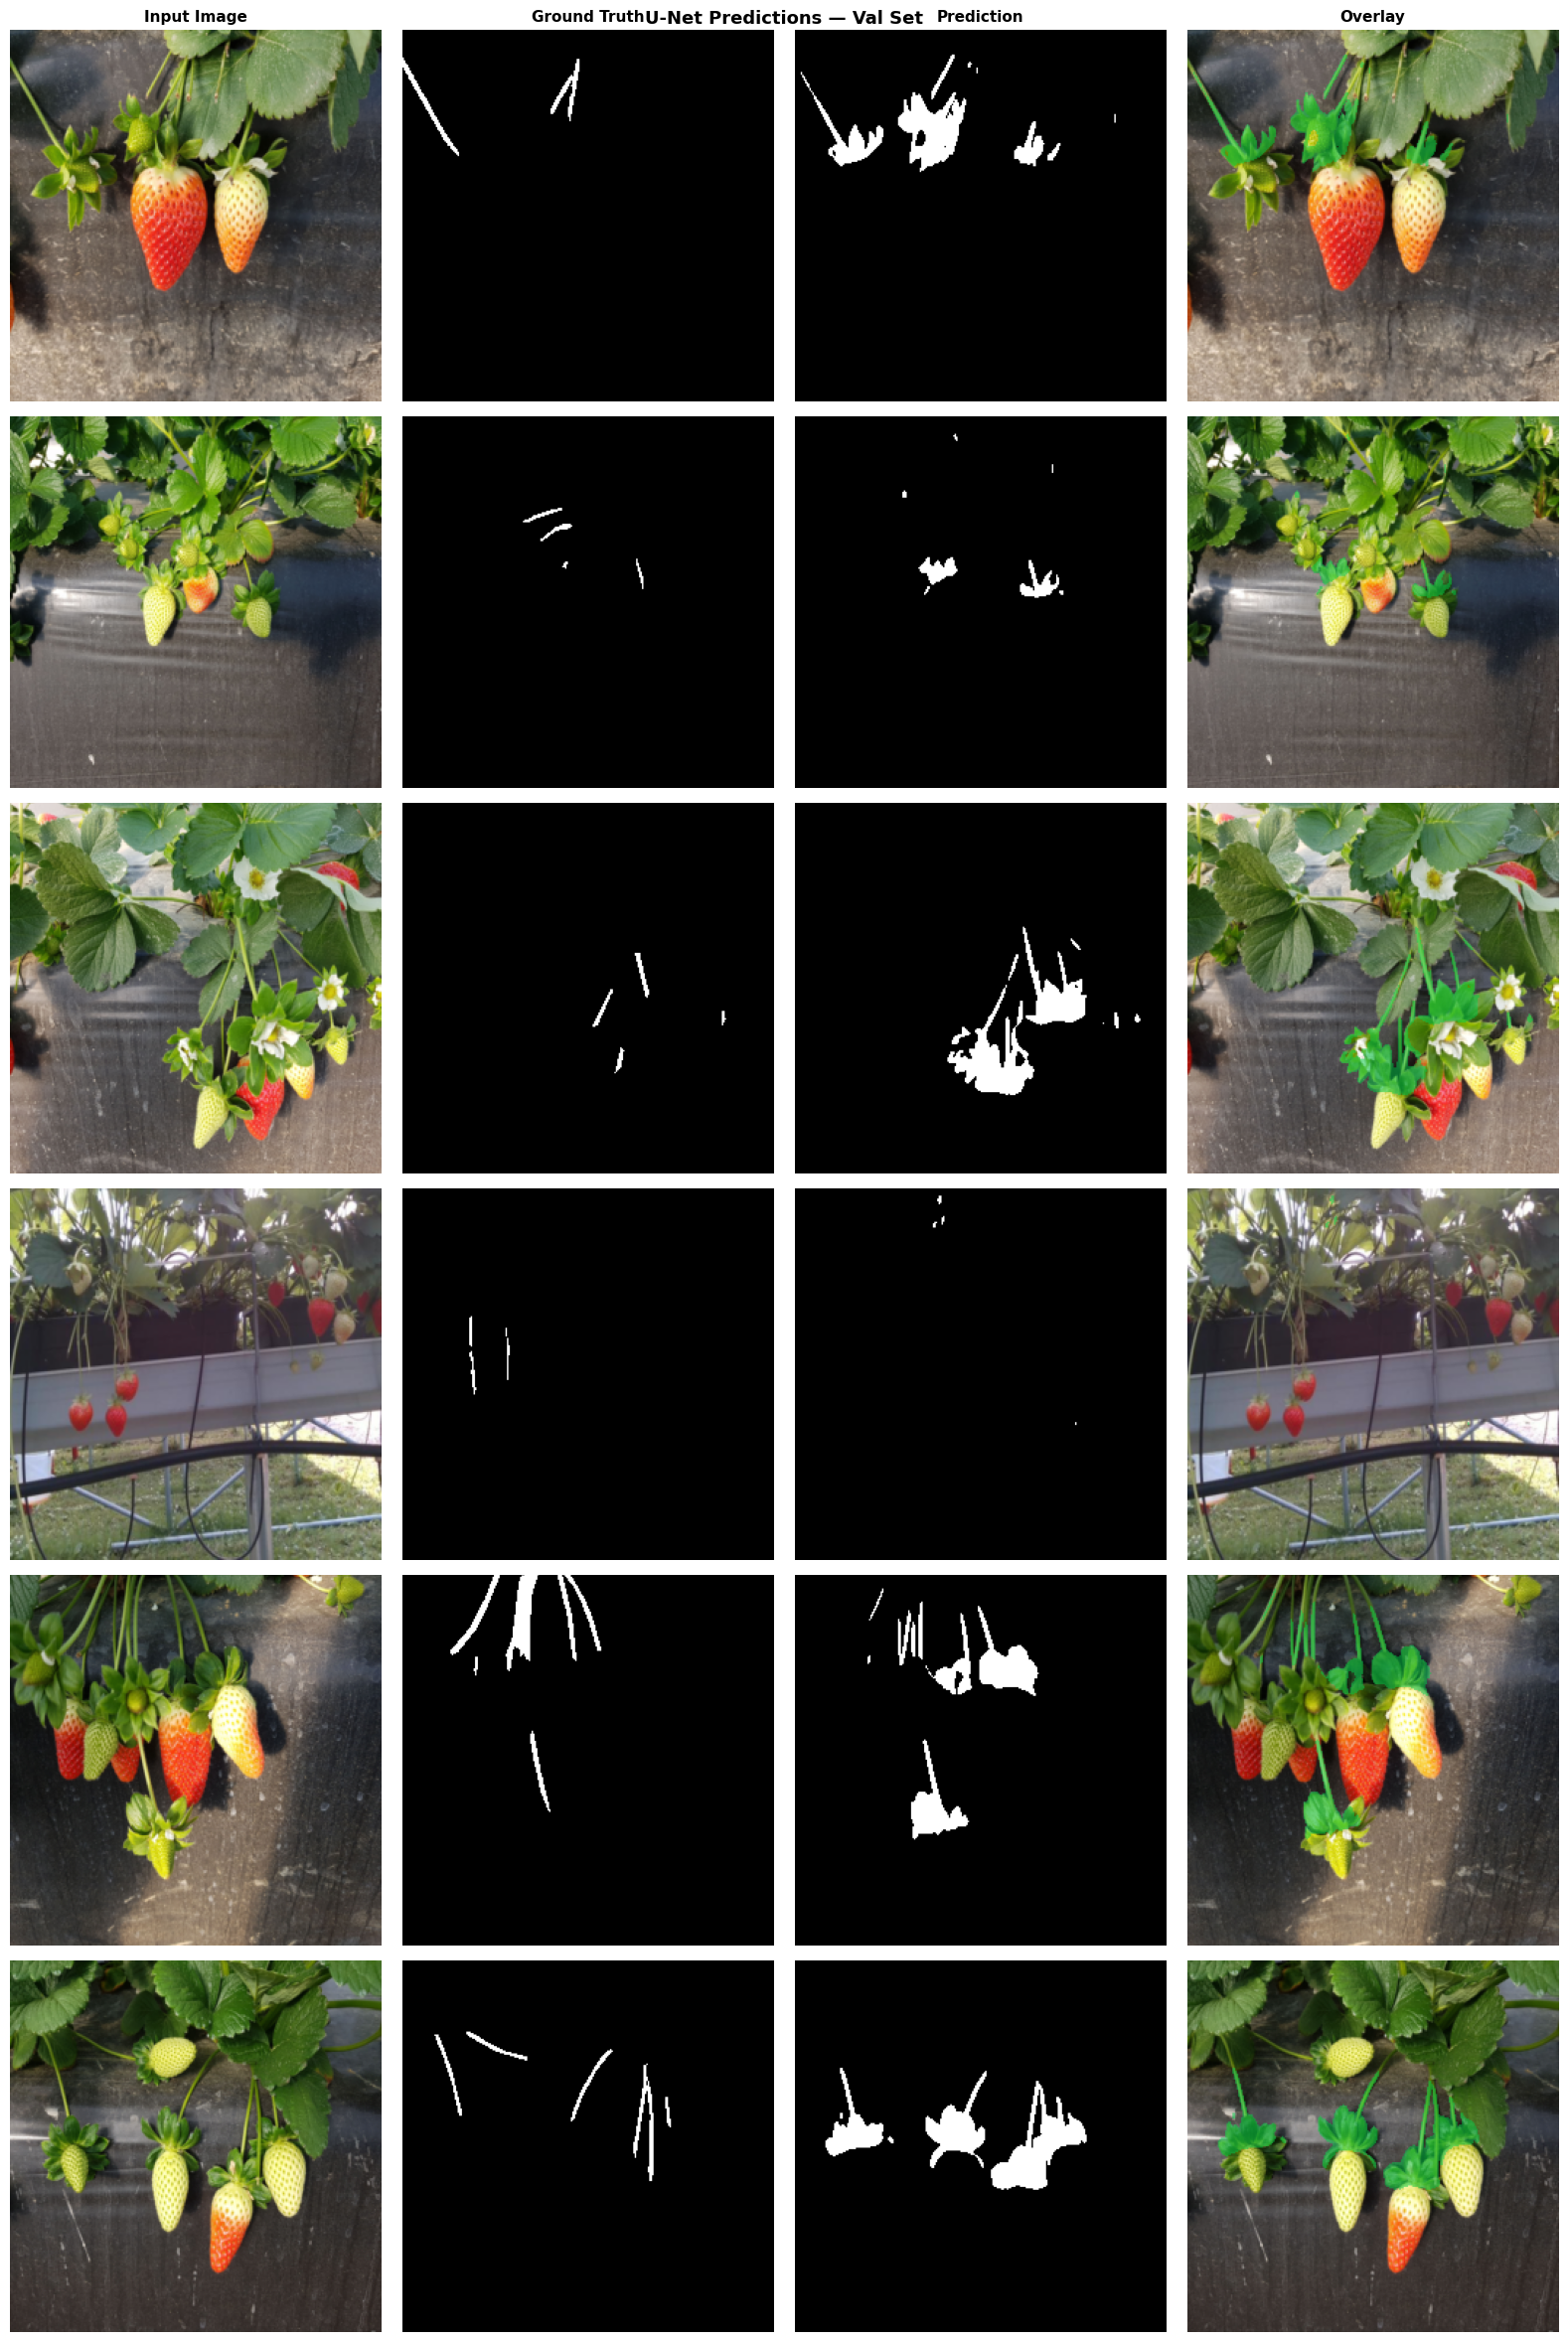

Saved: C:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\unet\unet_predictions.png


In [8]:
# Load best weights
model.load_state_dict(torch.load(best_weights, map_location=DEVICE))
model.eval()

# Denormalise for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

samples = random.sample(list(range(len(val_ds))), min(6, len(val_ds)))

fig, axes = plt.subplots(len(samples), 4, figsize=(16, len(samples) * 4))
fig.suptitle("U-Net Predictions — Val Set", fontsize=13, fontweight='bold')
col_titles = ["Input Image", "Ground Truth", "Prediction", "Overlay"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold')

for row, idx in enumerate(samples):
    img_t, mask_t = val_ds[idx]
    with torch.no_grad():
        pred = model(img_t.unsqueeze(0).to(DEVICE)).squeeze().cpu()

    # Denormalise image
    img_disp = (img_t * std + mean).clamp(0,1).permute(1,2,0).numpy()
    gt_disp  = mask_t.squeeze().numpy()
    pr_disp  = (pred > 0.5).float().numpy()

    # Overlay
    overlay = img_disp.copy()
    overlay[pr_disp == 1] = overlay[pr_disp == 1] * 0.5 + np.array([0, 0.8, 0.3]) * 0.5

    iou = iou_score(pred.unsqueeze(0), mask_t).item()

    axes[row][0].imshow(img_disp)
    axes[row][1].imshow(gt_disp,  cmap='gray')
    axes[row][2].imshow(pr_disp,  cmap='gray')
    axes[row][3].imshow(overlay)
    axes[row][3].set_ylabel(f"IoU: {iou:.3f}", fontsize=9)

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
pred_path = os.path.join(RUNS_DIR, "unet_predictions.png")
plt.savefig(pred_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {pred_path}")

## Cell 9 — Final Val Metrics Summary

In [9]:
model.load_state_dict(torch.load(best_weights, map_location=DEVICE))
model.eval()

all_iou, all_loss = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        all_iou.append(iou_score(preds, masks).item())
        all_loss.append(bce_dice_loss(preds, masks).item())

mean_iou  = np.mean(all_iou)
mean_loss = np.mean(all_loss)

print("=== U-Net Final Validation Metrics ===")
print(f"  Mean Val IoU:  {mean_iou:.4f}")
print(f"  Best Val IoU:  {best_val_iou:.4f}")
print(f"  Mean Val Loss: {mean_loss:.4f}")
print(f"  Train samples: {len(train_ds)}")
print(f"  Val samples:   {len(val_ds)}")
print(f"  Model weights: {best_weights}")

=== U-Net Final Validation Metrics ===
  Mean Val IoU:  0.2291
  Best Val IoU:  0.2291
  Mean Val Loss: 0.7485
  Train samples: 299
  Val samples:   58
  Model weights: C:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\unet\best_unet.pt
